In [1]:
import sys
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Sistema:", platform.platform())
print("NumPy:", np.__version__)
print("Ejecutable:", sys.executable)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Sistema: Windows-10-10.0.19045-SP0
NumPy: 2.4.6
Ejecutable: c:\venvs\taller3-train\Scripts\python.exe


In [2]:
def encontrar_raiz_proyecto(inicio: Path) -> Path:
    """
    Busca hacia arriba una carpeta que contenga 'regularizacion'.
    Esto evita depender de la carpeta desde donde VS Code abrió el kernel.
    """
    inicio = inicio.resolve()

    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / "regularizacion").exists():
            return carpeta

    raise FileNotFoundError(
        "No se encontró la carpeta 'regularizacion'. "
        "Abre el repositorio completo en VS Code."
    )


PROJECT_ROOT = encontrar_raiz_proyecto(Path.cwd())
REG_DIR = PROJECT_ROOT / "regularizacion"

DATA_V1_DIR = REG_DIR / "data" / "v1"
DATA_V2_DIR = REG_DIR / "data" / "v2"

OUTPUTS_V2_DIR = REG_DIR / "outputs" / "v2"
FIGURES_V2_DIR = OUTPUTS_V2_DIR / "figures"
METRICS_V2_DIR = OUTPUTS_V2_DIR / "metrics"
TENSORBOARD_V2_DIR = OUTPUTS_V2_DIR / "tensorboard"

MODELS_V2_DIR = REG_DIR / "models" / "v2"
CHECKPOINTS_V2_DIR = MODELS_V2_DIR / "checkpoints"
FINAL_V2_DIR = MODELS_V2_DIR / "final"
TFJS_V2_DIR = MODELS_V2_DIR / "tfjs"

for carpeta in [
    FIGURES_V2_DIR,
    METRICS_V2_DIR,
    TENSORBOARD_V2_DIR,
    CHECKPOINTS_V2_DIR,
    FINAL_V2_DIR,
    TFJS_V2_DIR,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", PROJECT_ROOT)
print("Dataset v1:", DATA_V1_DIR)
print("Dataset v2:", DATA_V2_DIR)

Raíz del proyecto: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3
Dataset v1: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v1
Dataset v2: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v2


In [4]:
rutas = {
    "X_v1": DATA_V1_DIR / "X.npy",
    "Y_v1": DATA_V1_DIR / "Y.npy",
    "X_v2": DATA_V2_DIR / "X.npy",
    "Y_v2": DATA_V2_DIR / "Y.npy",
}

for nombre, ruta in rutas.items():
    if not ruta.exists():
        raise FileNotFoundError(
            f"No se encontró {nombre} en:\n{ruta}"
        )

X_v1 = np.load(rutas["X_v1"], mmap_mode="r")
Y_v1 = np.load(rutas["Y_v1"], mmap_mode="r")

X_v2 = np.load(rutas["X_v2"], mmap_mode="r")
Y_v2 = np.load(rutas["Y_v2"], mmap_mode="r")

print("Archivos cargados correctamente.")

Archivos cargados correctamente.


In [5]:
def memoria_mb(arreglo: np.ndarray) -> float:
    return arreglo.nbytes / (1024 ** 2)


def mostrar_resumen(nombre: str, X: np.ndarray, Y: np.ndarray) -> None:
    print(nombre)
    print("-" * 55)
    print("Forma de X:", X.shape)
    print("Tipo de X:", X.dtype)
    print("Rango de X:", float(np.min(X)), "a", float(np.max(X)))
    print(f"Tamaño aproximado de X: {memoria_mb(X):.2f} MB")
    print()
    print("Forma de Y:", Y.shape)
    print("Tipo de Y:", Y.dtype)
    print("Rango de Y:", float(np.min(Y)), "a", float(np.max(Y)))
    print(f"Tamaño aproximado de Y: {memoria_mb(Y):.2f} MB")
    print()


mostrar_resumen("DATASET V1", X_v1, Y_v1)
mostrar_resumen("DATASET V2", X_v2, Y_v2)

print("Diferencia de cantidad de imágenes:", len(X_v2) - len(X_v1))

DATASET V1
-------------------------------------------------------
Forma de X: (2062, 64, 64)
Tipo de X: float32
Rango de X: 0.003921568859368563 a 1.0
Tamaño aproximado de X: 32.22 MB

Forma de Y: (2062, 10)
Tipo de Y: float64
Rango de Y: 0.0 a 1.0
Tamaño aproximado de Y: 0.16 MB

DATASET V2
-------------------------------------------------------
Forma de X: (5000, 64, 64)
Tipo de X: float32
Rango de X: 0.0 a 244.0
Tamaño aproximado de X: 78.12 MB

Forma de Y: (5000,)
Tipo de Y: int32
Rango de Y: 0.0 a 9.0
Tamaño aproximado de Y: 0.02 MB

Diferencia de cantidad de imágenes: 2938


In [6]:
def comprobar_integridad(nombre: str, X: np.ndarray, Y: np.ndarray) -> None:
    assert len(X) == len(Y), (
        f"{nombre}: X tiene {len(X)} elementos, "
        f"pero Y tiene {len(Y)}."
    )

    assert X.ndim in (3, 4), (
        f"{nombre}: X debería tener 3 o 4 dimensiones, "
        f"pero tiene {X.ndim}."
    )

    assert Y.ndim in (1, 2), (
        f"{nombre}: Y debería tener 1 o 2 dimensiones, "
        f"pero tiene {Y.ndim}."
    )

    assert np.isfinite(X).all(), (
        f"{nombre}: X contiene NaN o valores infinitos."
    )

    assert np.isfinite(Y).all(), (
        f"{nombre}: Y contiene NaN o valores infinitos."
    )

    print(f"{nombre}: comprobaciones básicas superadas.")


comprobar_integridad("Dataset v1", X_v1, Y_v1)
comprobar_integridad("Dataset v2", X_v2, Y_v2)

Dataset v1: comprobaciones básicas superadas.
Dataset v2: comprobaciones básicas superadas.


In [7]:
def obtener_indices_clase(Y: np.ndarray) -> np.ndarray:
    if Y.ndim == 2:
        return np.argmax(Y, axis=1)

    return Y.astype(int)


clases_v1 = obtener_indices_clase(Y_v1)
clases_v2 = obtener_indices_clase(Y_v2)

conteos_v1 = np.bincount(clases_v1, minlength=10)
conteos_v2 = np.bincount(clases_v2, minlength=10)

tabla_clases = pd.DataFrame({
    "Posicion_Y": np.arange(10),
    "Cantidad_v1": conteos_v1,
    "Cantidad_v2": conteos_v2,
    "Diferencia": conteos_v2 - conteos_v1,
})

tabla_clases

,Posicion_Y,Cantidad_v1,Cantidad_v2,Diferencia
0,0,204,500,296
1,1,205,500,295
2,2,206,500,294
3,3,207,500,293
4,4,206,500,294
5,5,208,500,292
6,6,207,500,293
7,7,206,500,294
8,8,206,500,294
9,9,207,500,293


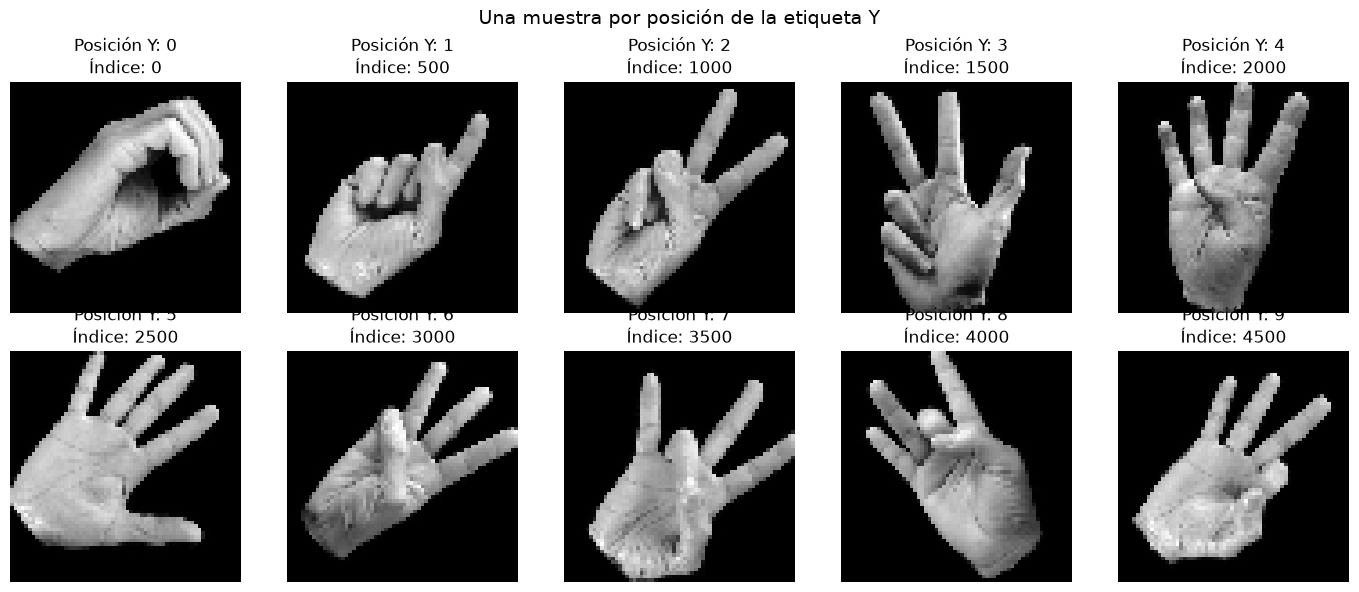

In [8]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(14, 6)
)

axes = axes.flatten()

for posicion in range(10):
    indices = np.where(clases_v2 == posicion)[0]

    if len(indices) == 0:
        axes[posicion].set_title(
            f"Posición Y: {posicion}\nSin imágenes"
        )
        axes[posicion].axis("off")
        continue

    indice = indices[0]
    imagen = np.asarray(X_v2[indice]).squeeze()

    axes[posicion].imshow(
        imagen,
        cmap="gray"
    )

    axes[posicion].set_title(
        f"Posición Y: {posicion}\nÍndice: {indice}"
    )

    axes[posicion].axis("off")

plt.suptitle(
    "Una muestra por posición de la etiqueta Y",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    FIGURES_V2_DIR / "muestras_orden_original_v2.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [9]:
import hashlib


def hash_imagen(imagen: np.ndarray) -> str:
    imagen_contigua = np.ascontiguousarray(imagen)

    return hashlib.blake2b(
        imagen_contigua.tobytes(),
        digest_size=16
    ).hexdigest()


print("Calculando identificadores del dataset v1...")

hashes_v1 = {
    hash_imagen(X_v1[indice])
    for indice in range(len(X_v1))
}

print("Calculando identificadores del dataset v2...")

hashes_v2_lista = [
    hash_imagen(X_v2[indice])
    for indice in range(len(X_v2))
]

hashes_v2 = set(hashes_v2_lista)

coincidencias = hashes_v1.intersection(hashes_v2)
duplicados_internos_v2 = len(hashes_v2_lista) - len(hashes_v2)

print("Imágenes únicas en v1:", len(hashes_v1))
print("Imágenes únicas en v2:", len(hashes_v2))
print("Imágenes de v1 encontradas exactamente en v2:", len(coincidencias))
print("Duplicados exactos dentro de v2:", duplicados_internos_v2)

porcentaje_v1_en_v2 = (
    len(coincidencias) / len(hashes_v1) * 100
)

print(
    f"Porcentaje de v1 presente exactamente en v2: "
    f"{porcentaje_v1_en_v2:.2f}%"
)

Calculando identificadores del dataset v1...
Calculando identificadores del dataset v2...
Imágenes únicas en v1: 2062
Imágenes únicas en v2: 4598
Imágenes de v1 encontradas exactamente en v2: 0
Duplicados exactos dentro de v2: 402
Porcentaje de v1 presente exactamente en v2: 0.00%


In [10]:
df_v2 = pd.DataFrame({
    "Indice": np.arange(len(X_v2)),
    "Clase": clases_v2,
    "Hash": hashes_v2_lista,
})

resumen_hashes = (
    df_v2
    .groupby("Hash")
    .agg(
        Cantidad=("Indice", "size"),
        Clases=(
            "Clase",
            lambda valores: tuple(
                sorted(set(valores))
            )
        ),
    )
    .reset_index()
)

resumen_hashes["Cantidad_clases"] = (
    resumen_hashes["Clases"].apply(len)
)

grupos_duplicados = resumen_hashes[
    resumen_hashes["Cantidad"] > 1
]

conflictos_etiqueta = resumen_hashes[
    resumen_hashes["Cantidad_clases"] > 1
]

print(
    "Grupos con imágenes repetidas:",
    len(grupos_duplicados)
)

print(
    "Grupos repetidos con etiquetas diferentes:",
    len(conflictos_etiqueta)
)

if len(conflictos_etiqueta) > 0:
    display(conflictos_etiqueta.head(20))
else:
    print(
        "Todos los duplicados mantienen "
        "la misma etiqueta."
    )

Grupos con imágenes repetidas: 357
Grupos repetidos con etiquetas diferentes: 0
Todos los duplicados mantienen la misma etiqueta.


In [11]:
indices_unicos_v2 = (
    df_v2
    .drop_duplicates(
        subset="Hash",
        keep="first"
    )["Indice"]
    .to_numpy()
)

clases_unicas_v2 = clases_v2[
    indices_unicos_v2
]

conteos_unicos_v2 = np.bincount(
    clases_unicas_v2,
    minlength=10
)

tabla_unicos_v2 = pd.DataFrame({
    "Digito": np.arange(10),
    "Cantidad_original": np.bincount(
        clases_v2,
        minlength=10
    ),
    "Cantidad_unica": conteos_unicos_v2,
})

tabla_unicos_v2["Duplicados_eliminados"] = (
    tabla_unicos_v2["Cantidad_original"]
    - tabla_unicos_v2["Cantidad_unica"]
)

tabla_unicos_v2

,Digito,Cantidad_original,Cantidad_unica,Duplicados_eliminados
0,0,500,420,80
1,1,500,499,1
2,2,500,499,1
3,3,500,420,80
4,4,500,484,16
5,5,500,500,0
6,6,500,449,51
7,7,500,418,82
8,8,500,410,90
9,9,500,499,1


In [12]:
def normalizar_temporalmente(
    X: np.ndarray
) -> np.ndarray:
    arreglo = np.asarray(
        X,
        dtype=np.float32
    )

    if arreglo.max() > 1.5:
        arreglo = arreglo / 255.0

    return np.clip(
        arreglo,
        0.0,
        1.0
    )


def calcular_media_borde(
    X: np.ndarray,
    cantidad_muestras: int = 300,
    ancho: int = 4
) -> np.ndarray:
    cantidad = min(
        cantidad_muestras,
        len(X)
    )

    indices = np.linspace(
        0,
        len(X) - 1,
        cantidad,
        dtype=int
    )

    muestras = normalizar_temporalmente(
        X[indices]
    )

    bordes = np.concatenate(
        [
            muestras[:, :ancho, :].reshape(
                cantidad,
                -1
            ),
            muestras[:, -ancho:, :].reshape(
                cantidad,
                -1
            ),
            muestras[:, :, :ancho].reshape(
                cantidad,
                -1
            ),
            muestras[:, :, -ancho:].reshape(
                cantidad,
                -1
            ),
        ],
        axis=1
    )

    return bordes.mean(axis=1)


bordes_v1 = calcular_media_borde(X_v1)
bordes_v2 = calcular_media_borde(X_v2)

print(
    "Promedio del fondo/borde en v1:",
    bordes_v1.mean()
)

print(
    "Promedio del fondo/borde en v2:",
    bordes_v2.mean()
)

print(
    "Porcentaje de imágenes v1 con fondo claro:",
    np.mean(bordes_v1 > 0.5) * 100
)

print(
    "Porcentaje de imágenes v2 con fondo claro:",
    np.mean(bordes_v2 > 0.5) * 100
)

Promedio del fondo/borde en v1: 0.6093819
Promedio del fondo/borde en v2: 0.020680135
Porcentaje de imágenes v1 con fondo claro: 99.66666666666667
Porcentaje de imágenes v2 con fondo claro: 0.0


## Preparación del dataset v2 limpio

El dataset v2 original contiene 5.000 imágenes, distribuidas inicialmente
en 500 muestras por cada dígito.

El análisis detectó 402 copias exactas, agrupadas en 357 grupos de
imágenes repetidas. No se encontraron imágenes idénticas asociadas a
etiquetas diferentes, por lo que las copias adicionales pueden eliminarse
de forma segura.

Después de la eliminación de duplicados, el dataset contiene 4.598
imágenes únicas. La cantidad por clase varía entre 410 y 500 muestras,
por lo que se utilizará una división estratificada para mantener las
proporciones de cada dígito en entrenamiento, validación y prueba.

El dataset será normalizado al intervalo entre 0 y 1, se agregará un
canal para obtener imágenes con forma 64 × 64 × 1 y se conservarán las
etiquetas como números enteros entre 0 y 9.

In [13]:
PROCESSED_V2_DIR = DATA_V2_DIR / "processed"
PROCESSED_V2_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Conserva solamente la primera aparición de cada imagen.
indices_unicos_v2 = (
    df_v2
    .drop_duplicates(
        subset="Hash",
        keep="first"
    )["Indice"]
    .to_numpy()
)

# Carga las imágenes únicas como float32.
X_clean = np.asarray(
    X_v2[indices_unicos_v2],
    dtype=np.float32
)

# Normalización estándar de píxeles:
# 0–255 pasa a 0–1.
X_clean = X_clean / 255.0

X_clean = np.clip(
    X_clean,
    0.0,
    1.0
)

# Agrega el canal de escala de grises.
# (4598, 64, 64) → (4598, 64, 64, 1)
if X_clean.ndim == 3:
    X_clean = X_clean[..., np.newaxis]

# Etiquetas enteras entre 0 y 9.
Y_clean = clases_v2[
    indices_unicos_v2
].astype(np.int32)

print("Dataset v2 limpio")
print("-" * 50)
print("Forma de X:", X_clean.shape)
print("Tipo de X:", X_clean.dtype)
print(
    "Rango de X:",
    float(X_clean.min()),
    "a",
    float(X_clean.max())
)
print()
print("Forma de Y:", Y_clean.shape)
print("Tipo de Y:", Y_clean.dtype)
print(
    "Clases presentes:",
    np.unique(Y_clean)
)

Dataset v2 limpio
--------------------------------------------------
Forma de X: (4598, 64, 64, 1)
Tipo de X: float32
Rango de X: 0.0 a 0.95686274766922

Forma de Y: (4598,)
Tipo de Y: int32
Clases presentes: [0 1 2 3 4 5 6 7 8 9]


In [14]:
metadata_clean = pd.DataFrame({
    "Indice_limpio": np.arange(len(indices_unicos_v2)),
    "Indice_original": indices_unicos_v2,
    "Digito": Y_clean,
    "Hash": [
        hashes_v2_lista[indice]
        for indice in indices_unicos_v2
    ]
})

metadata_clean.head()

,Indice_limpio,Indice_original,Digito,Hash
0,0,0,0,58f4675670d2724cb2f65396a80e7a45
1,1,1,0,71a51d8d4edc230e34ca076941ae10ce
2,2,2,0,222390e188740bc548b2f4bd5ce10581
3,3,3,0,c74f2897d43d0489b26d60ee3b9f64e4
4,4,4,0,34ab233aa8d353677e356863ff495679


In [15]:
ruta_x_clean = (
    PROCESSED_V2_DIR / "X_clean.npy"
)

ruta_y_clean = (
    PROCESSED_V2_DIR / "Y_clean.npy"
)

ruta_metadata_clean = (
    PROCESSED_V2_DIR / "metadata_clean.csv"
)

np.save(
    ruta_x_clean,
    X_clean
)

np.save(
    ruta_y_clean,
    Y_clean
)

metadata_clean.to_csv(
    ruta_metadata_clean,
    index=False
)

print("Archivos guardados:")
print(ruta_x_clean)
print(ruta_y_clean)
print(ruta_metadata_clean)

Archivos guardados:
C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v2\processed\X_clean.npy
C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v2\processed\Y_clean.npy
C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v2\processed\metadata_clean.csv


In [16]:
from sklearn.model_selection import train_test_split

SEED = 42

indices_totales = np.arange(
    len(Y_clean)
)

indices_train, indices_temporales = train_test_split(
    indices_totales,
    test_size=0.20,
    random_state=SEED,
    stratify=Y_clean
)

indices_val, indices_test = train_test_split(
    indices_temporales,
    test_size=0.50,
    random_state=SEED,
    stratify=Y_clean[indices_temporales]
)

print("Cantidad total:", len(indices_totales))
print("Entrenamiento:", len(indices_train))
print("Validación:", len(indices_val))
print("Prueba:", len(indices_test))

print()
print(
    "Porcentaje entrenamiento:",
    len(indices_train) / len(indices_totales) * 100
)

print(
    "Porcentaje validación:",
    len(indices_val) / len(indices_totales) * 100
)

print(
    "Porcentaje prueba:",
    len(indices_test) / len(indices_totales) * 100
)

Cantidad total: 4598
Entrenamiento: 3678
Validación: 460
Prueba: 460

Porcentaje entrenamiento: 79.99130056546323
Porcentaje validación: 10.004349717268378
Porcentaje prueba: 10.004349717268378


In [17]:
def contar_clases(
    etiquetas: np.ndarray
) -> np.ndarray:
    return np.bincount(
        etiquetas,
        minlength=10
    )


tabla_division = pd.DataFrame({
    "Digito": np.arange(10),
    "Total": contar_clases(Y_clean),
    "Entrenamiento": contar_clases(
        Y_clean[indices_train]
    ),
    "Validacion": contar_clases(
        Y_clean[indices_val]
    ),
    "Prueba": contar_clases(
        Y_clean[indices_test]
    ),
})

tabla_division

,Digito,Total,Entrenamiento,Validacion,Prueba
0,0,420,336,42,42
1,1,499,399,50,50
2,2,499,399,50,50
3,3,420,336,42,42
4,4,484,387,48,49
5,5,500,400,50,50
6,6,449,359,45,45
7,7,418,335,42,41
8,8,410,328,41,41
9,9,499,399,50,50


In [18]:
ruta_splits = (
    PROCESSED_V2_DIR / "split_indices.npz"
)

np.savez(
    ruta_splits,
    train=indices_train,
    validation=indices_val,
    test=indices_test,
    seed=np.array([SEED])
)

tabla_division.to_csv(
    METRICS_V2_DIR / "distribucion_splits_v2.csv",
    index=False
)

print("Divisiones guardadas en:")
print(ruta_splits)

Divisiones guardadas en:
C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v2\processed\split_indices.npz


In [19]:
hashes_clean = metadata_clean["Hash"].to_numpy()

hashes_train = set(
    hashes_clean[indices_train]
)

hashes_val = set(
    hashes_clean[indices_val]
)

hashes_test = set(
    hashes_clean[indices_test]
)

print(
    "Coincidencias train-validación:",
    len(
        hashes_train.intersection(
            hashes_val
        )
    )
)

print(
    "Coincidencias train-prueba:",
    len(
        hashes_train.intersection(
            hashes_test
        )
    )
)

print(
    "Coincidencias validación-prueba:",
    len(
        hashes_val.intersection(
            hashes_test
        )
    )
)

Coincidencias train-validación: 0
Coincidencias train-prueba: 0
Coincidencias validación-prueba: 0


## Conclusión de la preparación del dataset

El dataset v2 original contenía 5.000 imágenes. Durante la inspección
se identificaron 402 copias exactas, agrupadas en 357 grupos de
imágenes repetidas. No se encontraron duplicados asociados a etiquetas
diferentes.

Después de eliminar las copias adicionales, el dataset quedó compuesto
por 4.598 imágenes únicas de 64 × 64 píxeles. Las imágenes fueron
normalizadas al intervalo entre 0 y 1 y se agregó un canal para obtener
la forma requerida por la red convolucional: 64 × 64 × 1.

Las etiquetas se conservaron como números enteros entre 0 y 9. El
dataset fue dividido de manera estratificada en 79,99 % para
entrenamiento, 10 % para validación y 10 % para prueba.

Finalmente, se comprobó que no existen imágenes idénticas compartidas
entre entrenamiento, validación y prueba, evitando así una fuga de
datos exacta entre los conjuntos.